In [1]:
import matplotlib.pyplot as plt
from oqtant.schemas.quantum_matter import QuantumMatterFactory
from matplotlib import pyplot as plt
import numpy as np
from scipy.ndimage import rotate
from scipy.optimize import curve_fit
from copy import deepcopy

qmf = QuantumMatterFactory()
qmf.get_login()

Auth(children=(HBox(children=(Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x12\x00\x00\x00\xc…

In [2]:
qmf.get_client()

Job Limits:
╒═══════════════╤═══════════════════╤════════════════════╤════════════════════╕
│   Daily Limit │   Daily Remaining │   Standard Credits │   Priority Credits │
╞═══════════════╪═══════════════════╪════════════════════╪════════════════════╡
│            20 │                20 │                 84 │                  0 │
╘═══════════════╧═══════════════════╧════════════════════╧════════════════════╛


In [7]:
base_filename = "Data/NoPatternExpt_rep_"
num_runs = 3

no_pattern = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

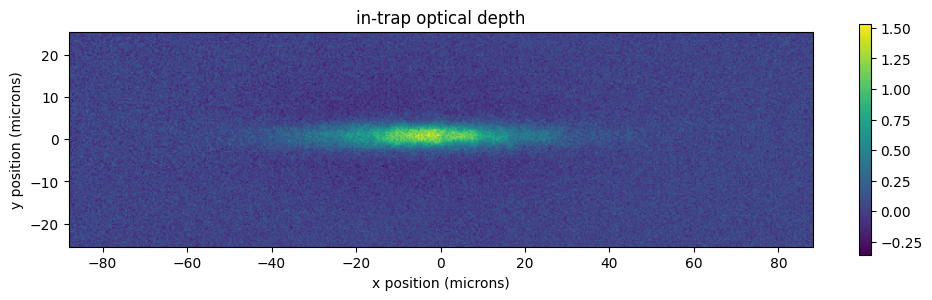

In [8]:
no_pattern[0].output.plot_it()

In [9]:
base_filename = "Data/LongOnlyExpt_rep_"
num_runs = 3

long_only = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

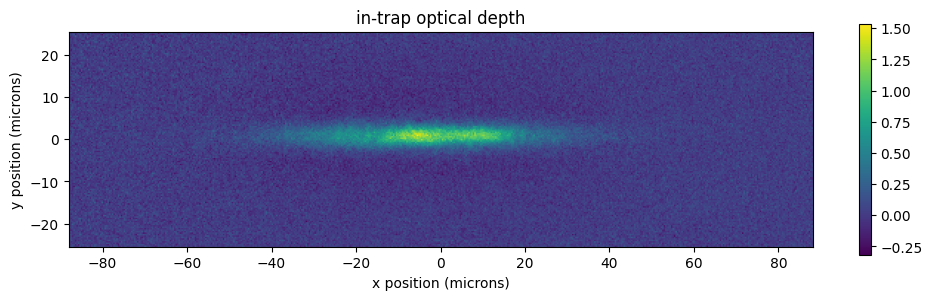

In [11]:
long_only[0].output.plot_it()

In [12]:
base_filename = "Data/ShortOnlyExpt_rep_"
num_runs = 3

short_only = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

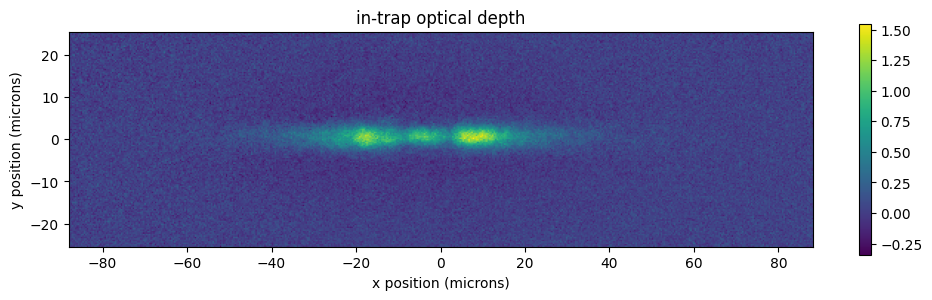

In [13]:
short_only[0].output.plot_it()

In [15]:
base_filename = "Data/SuperlatticeExp_rep_"
num_runs = 3

superlattice = [
    qmf.load_matter_from_file(f"{base_filename}{i:d}.txt", refresh=False)
    for i in range(num_runs)
]

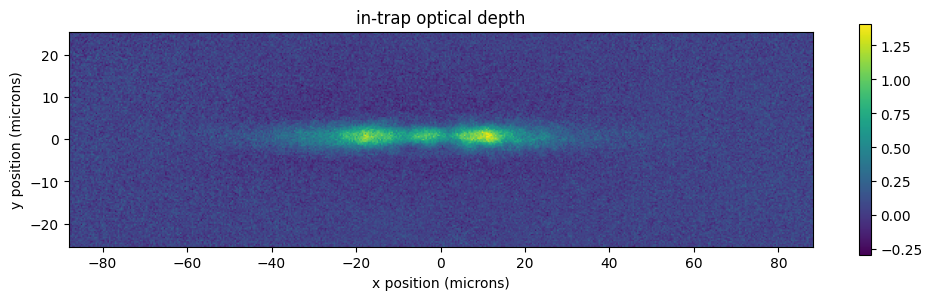

In [20]:
superlattice[2].output.plot_it()

In [29]:
def averageMatterImages(matters, imaging):
    rows = matters[0].output.it_plot.rows
    columns = matters[0].output.it_plot.columns
    pixcal = matters[0].output.get_image_pixcal(image=imaging)
    avg_pixels = np.zeros((rows, columns))
    avg_slice = np.zeros(columns)
    
    for matter in matters:
        avg_pixels += matter.output.get_image_data(image=imaging)
        avg_slice += matter.output.get_image_data(image=imaging)[int(rows / 2)]
        
    num_runs = len(matters)
    avg_pixels /= num_runs
    avg_slice /= num_runs
    
    x_pos = np.arange(-columns / 2 * pixcal, columns / 2 * pixcal, pixcal)
    y_pos = np.arange(-rows / 2 * pixcal, rows / 2 * pixcal, pixcal)

    return avg_pixels, avg_slice, x_pos, y_pos

In [30]:
def plotAveragedImages(pixels, slices, xpos, ypos, title):
    fig, axs = plt.subplots(nrows=2, sharex=True)
    fig.suptitle(title)
    im = axs[0].imshow(pixels,
                       extent=[xpos[0], xpos[-1], 
                               ypos[0], ypos[-1]],
                      )
    cbaxes = fig.add_axes([0.15, 0.6, 0.15, 0.02])
    cb = plt.colorbar(im, cax=cbaxes, ticks=[0.0, 1], orientation="horizontal")
    cbaxes.tick_params(color="w", labelcolor="w")
    
    axs[1].plot(xpos, slices, label="Slice @ Y=0")
    axs[1].set_ylabel("Optical Depth")
    axs[1].set_yticks([0, 0.5, 1])
    axs[1].set_xlabel("X position ($\mu$m)")
    axs[1].legend()
    axs[0].set_ylabel("Y position ($\mu$m)")
    plt.subplots_adjust(hspace=0)
    plt.show()

In [33]:
pix, slic, x, y = averageMatterImages(no_pattern, "IN_TRAP")

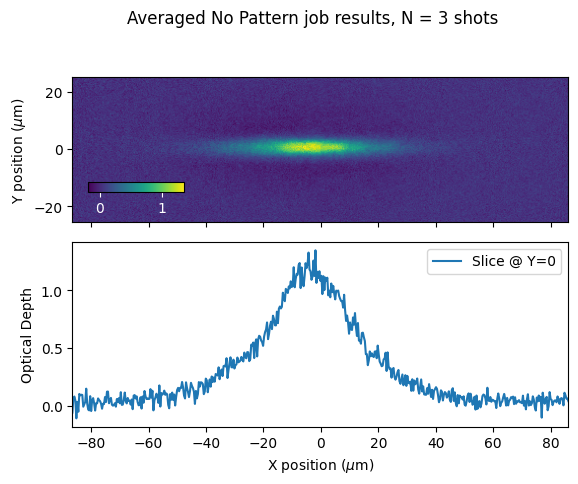

In [35]:
plotAveragedImages(pix, slic, x, y, "Averaged No Pattern job results, N = 3 shots")

In [36]:
pix, slic, x, y = averageMatterImages(long_only, "IN_TRAP")

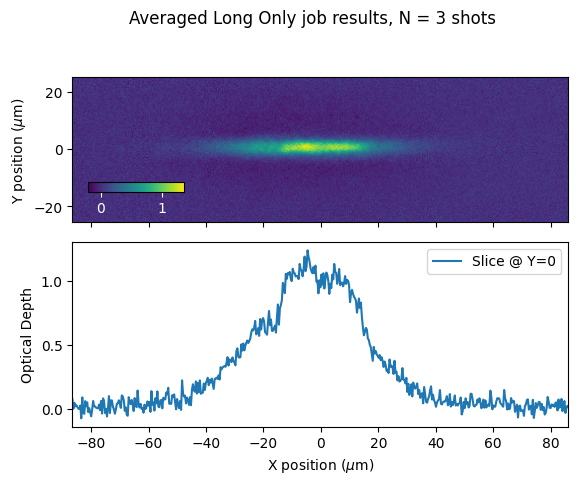

In [37]:
plotAveragedImages(pix, slic, x, y, "Averaged Long Only job results, N = 3 shots")

In [38]:
pix, slic, x, y = averageMatterImages(short_only, "IN_TRAP")

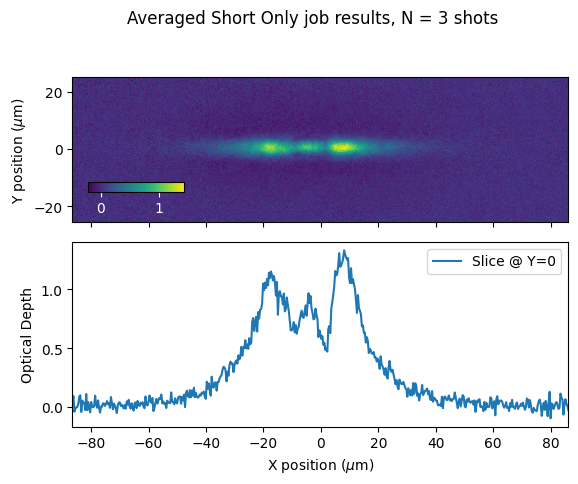

In [39]:
plotAveragedImages(pix, slic, x, y, "Averaged Short Only job results, N = 3 shots")

In [ ]:
pix, slic, x, y = averageMatterImages(superlattice, "IN_TRAP")

In [ ]:
plotAveragedImages(pix, slic, x, y, "Averaged Superlattice job results, N = 3 shots")